# Métodos de búsqueda

Nombre: Valeria Estefanía Milke Loera

Expediente: 739228

Fecha: 23-03-2026
__________________

En este ejercicio se implementa un modelo de regresión basado en Procesos Gaussianos con el objetivo de ajustar una función a un conjunto de datos y analizar tanto la predicción como la incertidumbre del modelo.

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler

**Ajuste inicial**

In [88]:
x = np.array([10,2,3,7,12]).reshape(-1,1)
y = np.array([2847,-4017,-1255,1773,563])

In [90]:
gp = GaussianProcessRegressor(n_restarts_optimizer=10)

In [91]:
gp.fit(x,y)

GaussianProcessRegressor(n_restarts_optimizer=10)

In [92]:
xsim = np.linspace(2,15, 10001).reshape(-1,1)

In [93]:
ypred, sigma = gp.predict(xsim,return_std=True)
ypred, sigma

(array([-4.01700000e+03, -4.01552264e+03, -4.01403659e+03, ...,
         2.06700829e+00,  2.05894051e+00,  2.05090082e+00]),
 array([1.00000004e-05, 8.39809338e-04, 1.67800358e-03, ...,
        9.99936160e-01, 9.99936655e-01, 9.99937147e-01]))

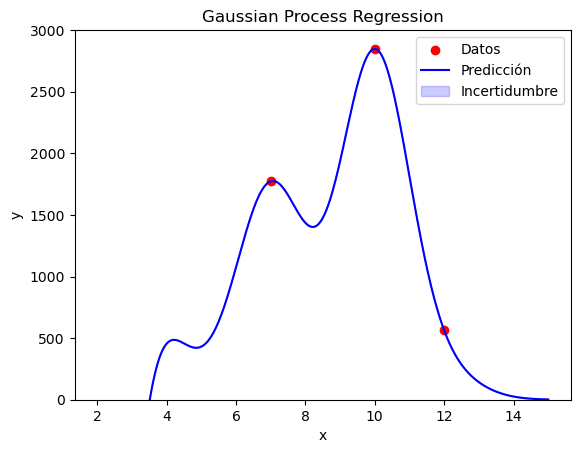

In [109]:
plt.figure()
plt.scatter(x, y, color='red', label='Datos')
plt.plot(xsim, ypred, color='blue', label='Predicción')

plt.fill_between(
    xsim.ravel(),
    ypred + 2*sigma,
    ypred - 2*sigma,
    color='blue',
    alpha=0.2,
    label='Incertidumbre'
)
plt.ylim(0,3000)
plt.legend()
plt.title("Gaussian Process Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [95]:
i_max = np.argmax(ypred + 2*sigma)
i_max

np.int64(6151)

In [96]:
xsim[i_max]

array([9.9963])

________________________

**Incorporación de nuevos datos**

In [97]:
x1 = np.array([10,2,3,7,12,9.9963]).reshape(-1,1)
y1 = np.array([2847,-4017,-1255,1773,563,2847.31363])

In [98]:
gp1 = GaussianProcessRegressor(n_restarts_optimizer=10)

In [99]:
gp1.fit(x1,y1)

GaussianProcessRegressor(n_restarts_optimizer=10)

In [100]:
xsim1 = np.linspace(2,15, 10001).reshape(-1,1)

In [113]:
ypred1, sigma1 = gp1.predict(xsim1,return_std=True)
ypred1, sigma1

(array([-4.01700000e+03, -4.01552264e+03, -4.01403658e+03, ...,
         2.33536929e+00,  2.32626147e+00,  2.31718532e+00]),
 array([1.00000004e-05, 8.39809338e-04, 1.67800358e-03, ...,
        9.99931110e-01, 9.99931645e-01, 9.99932175e-01]))

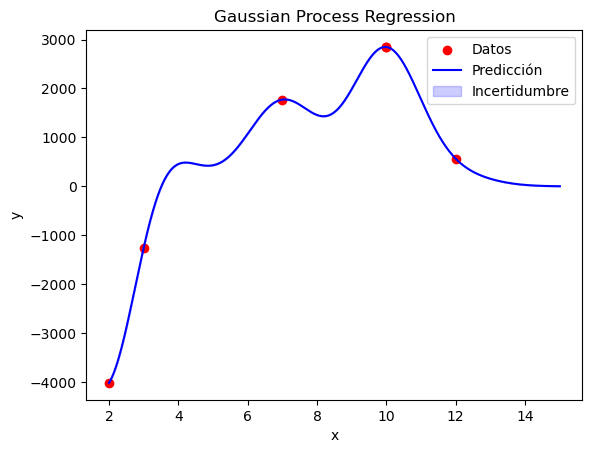

In [114]:
plt.figure()
plt.scatter(x1, y1, color='red', label='Datos')
plt.plot(xsim1, ypred1, color='blue', label='Predicción')

plt.fill_between(
    xsim1.ravel(),
    ypred1 + 2*sigma1,
    ypred1 - 2*sigma1,
    color='blue',
    alpha=0.2,
    label='Incertidumbre'
)
plt.legend()
plt.title("Gaussian Process Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [115]:
i_max1 = np.argmax(ypred1 + 2*sigma1)
i_max1

np.int64(6127)

In [116]:
xsim1[i_max1]

array([9.9651])

_________________________

**Actualización de datos**

In [120]:
x2 = np.array([10,2,3,7,12,9.9963,9.9651]).reshape(-1,1)
y2 = np.array([2847,-4017,-1255,1773,563,2847.31363,2849.5981])

In [121]:
gp2 = GaussianProcessRegressor(n_restarts_optimizer=10)

In [122]:
gp2.fit(x2,y2)

GaussianProcessRegressor(n_restarts_optimizer=10)

In [123]:
xsim2 = np.linspace(2,15, 10001).reshape(-1,1)

In [124]:
ypred2, sigma2 = gp2.predict(xsim2,return_std=True)
ypred2, sigma2

(array([-4016.99999948, -4015.52259822, -4014.03649807, ...,
           -4.66365792,    -4.64575023,    -4.62790298]),
 array([1.00000004e-05, 8.39809337e-04, 1.67800358e-03, ...,
        9.99919299e-01, 9.99919924e-01, 9.99920546e-01]))

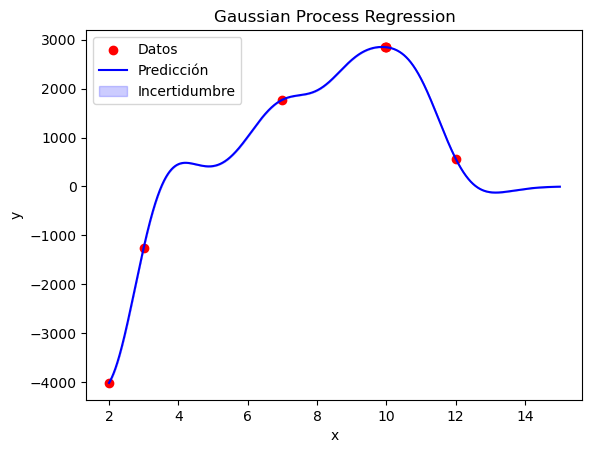

In [125]:
plt.figure()
plt.scatter(x2, y2, color='red', label='Datos')
plt.plot(xsim2, ypred2, color='blue', label='Predicción')

plt.fill_between(
    xsim2.ravel(),
    ypred2 + 2*sigma2,
    ypred2 - 2*sigma2,
    color='blue',
    alpha=0.2,
    label='Incertidumbre'
)
plt.legend()
plt.title("Gaussian Process Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [126]:
i_max2 = np.argmax(ypred2 + 2*sigma2)
i_max2

np.int64(6057)

In [127]:
xsim2[i_max2]

array([9.8741])

_____________________

**Refinamiento de la predicción**

In [128]:
x3 = np.array([10,2,3,7,12,9.9963,9.9651,9.8741]).reshape(-1,1)
y3 = np.array([2847,-4017,-1255,1773,563,2847.31363,2849.5981,2852.69711])

In [129]:
gp3 = GaussianProcessRegressor(n_restarts_optimizer=10)

In [130]:
gp3.fit(x3,y3)

GaussianProcessRegressor(n_restarts_optimizer=10)

In [131]:
xsim3 = np.linspace(2,15, 10001).reshape(-1,1)

In [132]:
ypred3, sigma3 = gp3.predict(xsim3,return_std=True)
ypred3, sigma3

(array([-4016.99999948, -4015.52259274, -4014.0364871 , ...,
           -4.328851  ,    -4.31222205,    -4.29564926]),
 array([1.00000004e-05, 8.39809337e-04, 1.67800358e-03, ...,
        9.99918122e-01, 9.99918757e-01, 9.99919387e-01]))

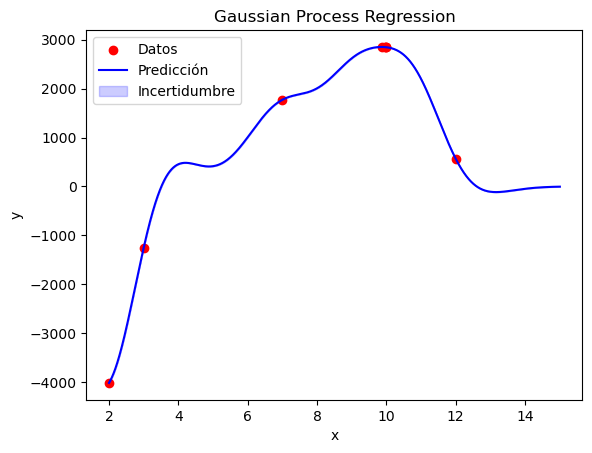

In [133]:
plt.figure()
plt.scatter(x3, y3, color='red', label='Datos')
plt.plot(xsim3, ypred3, color='blue', label='Predicción')

plt.fill_between(
    xsim3.ravel(),
    ypred3 + 2*sigma3,
    ypred3 - 2*sigma3,
    color='blue',
    alpha=0.2,
    label='Incertidumbre'
)
plt.legend()
plt.title("Gaussian Process Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [134]:
i_max3 = np.argmax(ypred3 + 2*sigma3)
i_max3

np.int64(6049)

In [136]:
xsim3[i_max3]

array([9.8637])

_________________________

### Resultados

El modelo fue entrenado correctamente y se generaron predicciones sobre nuevos valores de entrada. Se obtuvo una curva suave que se ajusta a los datos originales, lo cual indica que el modelo logró capturar la relación subyacente entre las variables.

### Interpretación de las gráficas

En la gráfica se observan tres elementos principales:

- Los puntos negros representan los datos originales.
- La línea azul corresponde a la predicción del modelo.
- La banda de incertidumbre representa el intervalo de confianza del modelo.

Se observa que el modelo ajusta correctamente los puntos de datos y la incertidumbre es menor cerca de los puntos observados y mayor en las zonas donde no hay datos, lo cual es consistente con el comportamiento esperado de un proceso gaussiano.
Sin embargo, debido a la escala de los datos, la incertidumbre no es fácilmente visible, ya que la desviación estándar es pequeña en comparación con los valores de la variable dependiente.

### Conclusión

El modelo de Gaussian Process Regression permitió ajustar de manera efectiva una función a los datos observados, capturando su comportamiento de forma suave y flexible.

Una de las principales ventajas del GPR es que no solo proporciona una predicción, sino también una medida de incertidumbre, lo cual es útil para evaluar la confiabilidad del modelo.
En general, el GPR es una herramienta poderosa para modelar relaciones complejas cuando se desea incorporar información probabilística en las predicciones.